X = [[4.17022005e-01 7.20324493e-01]
 [1.14374817e-04 3.02332573e-01]
 [1.46755891e-01 9.23385948e-02]
 [1.86260211e-01 3.45560727e-01]
 [3.96767474e-01 5.38816734e-01]
 [4.19194514e-01 6.85219500e-01]
 [2.04452250e-01 8.78117436e-01]
 [2.73875932e-02 6.70467510e-01]
 [4.17304802e-01 5.58689828e-01]
 [1.40386939e-01 1.98101489e-01]]
Shape of X: (10, 2)


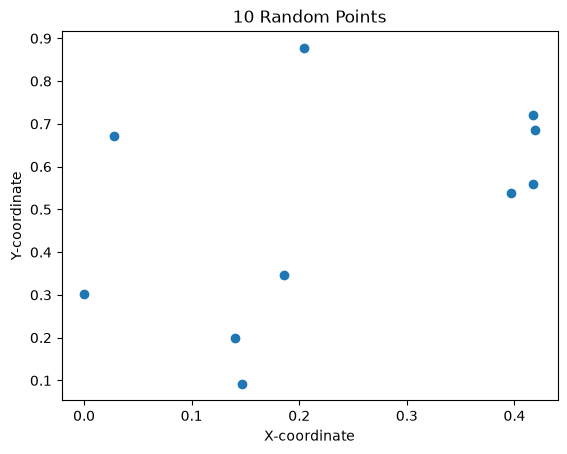

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed random seed
np.random.seed(1)

# Generate 10 random points with 2 coordinates each
X = np.random.rand(10, 2)

print("X =",X)


print("Shape of X:", X.shape)

# Plot the points
plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("10 Random Points")

plt.show()



In [10]:
D2 = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :])**2, axis=2)

print("Squared distance matrix:")
print(D2)

diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]

print("Coordinate differences shape:", diff.shape)

sq_diff = diff ** 2

print("Squared differences shape:", sq_diff.shape)


D2 = np.sum(sq_diff, axis=2)

print("Summed squared distances shape:", D2.shape)

Squared distance matrix:
[[0.         0.34852922 0.46741006 0.19369889 0.03335531 0.00123708
  0.07008451 0.15430069 0.02612584 0.34924383]
 [0.34852922 0.         0.0656012  0.03651895 0.21325844 0.32223056
  0.37328218 0.13626716 0.2397669  0.03054051]
 [0.46741006 0.0656012  0.         0.06568204 0.26184852 0.42573057
  0.62077726 0.34848183 0.29068019 0.01122635]
 [0.19369889 0.03651895 0.06568204 0.         0.08166119 0.16962647
  0.2839476  0.13080493 0.09880562 0.02384858]
 [0.03335531 0.21325844 0.26184852 0.08166119 0.         0.02193674
  0.15211011 0.15377342 0.00081672 0.18181786]
 [0.00123708 0.32223056 0.42573057 0.16962647 0.02193674 0.
  0.08332385 0.15373028 0.01601333 0.31501762]
 [0.07008451 0.37328218 0.62077726 0.2839476  0.15211011 0.08332385
  0.         0.07447038 0.14734021 0.46652605]
 [0.15430069 0.13626716 0.34848183 0.13080493 0.15377342 0.15373028
  0.07447038 0.         0.16452968 0.23589851]
 [0.02612584 0.2397669  0.29068019 0.09880562 0.00081672 0.0160

In [3]:
diagonal = np.diag(D2)

print("Diagonal:")
print(diagonal)

print("Are all diagonal values zero?", np.all(diagonal == 0))

Diagonal:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Are all diagonal values zero? True


In [4]:
neighbor_order = np.argsort(D2, axis=1)

print("Neighbor ordering:",neighbor_order)

K = 2

nearest = np.argpartition(D2, K, axis=1)[:, :K+1]

print("K+1 nearest points:",nearest)


nearest_neighbors = np.array([
    row[row != i][:K]
    for i, row in enumerate(nearest) ])

print("2 nearest neighbors:")
print(nearest_neighbors)


Neighbor ordering: [[0 5 8 4 6 7 3 1 9 2]
 [1 9 3 2 7 4 8 5 0 6]
 [2 9 1 3 4 8 7 5 0 6]
 [3 9 1 2 4 8 7 5 0 6]
 [4 8 5 0 3 6 7 9 1 2]
 [5 0 8 4 6 7 3 9 1 2]
 [6 0 7 5 8 4 3 1 9 2]
 [7 6 3 1 5 4 0 8 9 2]
 [8 4 5 0 3 6 7 9 1 2]
 [9 2 3 1 4 8 7 5 0 6]]
K+1 nearest points: [[0 5 8]
 [1 9 3]
 [2 9 1]
 [3 9 1]
 [4 8 5]
 [5 0 8]
 [6 0 7]
 [7 6 3]
 [8 4 5]
 [9 2 3]]
2 nearest neighbors:
[[5 8]
 [9 3]
 [9 1]
 [9 1]
 [8 5]
 [0 8]
 [0 7]
 [6 3]
 [4 5]
 [2 3]]


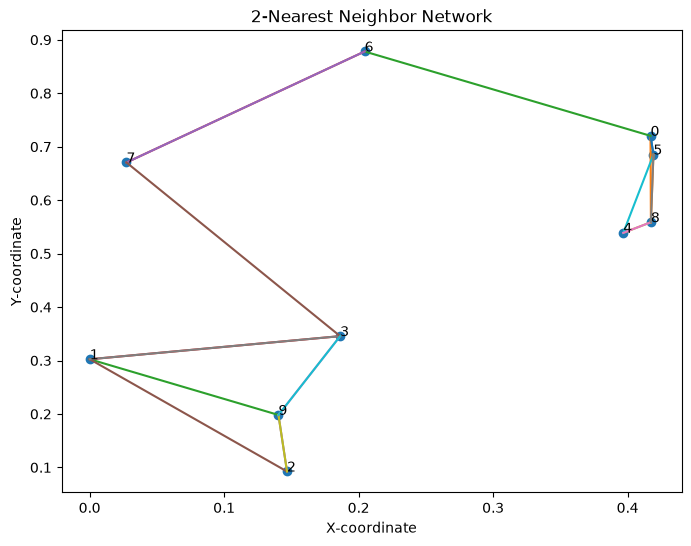

In [7]:
plt.figure(figsize=(8, 6))

# Plot points
plt.scatter(X[:, 0], X[:, 1])

# Add point numbers
for i in range(len(X)):
    plt.text(X[i, 0], X[i, 1], str(i))

# Draw lines to 2 nearest neighbors
for i in range(len(X)):
    for j in nearest_neighbors[i]:
        plt.plot(
            [X[i, 0], X[j, 0]],
            [X[i, 1], X[j, 1]]
        )

plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("2-Nearest Neighbor Network")

plt.show()

In [11]:
def loop_nearest_neighbors(X, K=2):
    N = len(X)

    result = []

    for i in range(N):
        distances = []

        for j in range(N):
            distance = np.sum((X[i] - X[j]) ** 2)
            distances.append(distance)

        order = np.argsort(distances)

        # Remove the point itself
        neighbors = [x for x in order if x != i][:K]

        result.append(neighbors)

    return np.array(result)

result = loop_nearest_neighbors(X, 2)

print(result)

[[5 8]
 [9 3]
 [9 1]
 [9 1]
 [8 5]
 [0 8]
 [0 7]
 [6 3]
 [4 5]
 [2 3]]


In [12]:
def vectorized_nearest_neighbors(X, K=2):

    D2 = np.sum(
        (X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2,
        axis=2
    )

    nearest = np.argpartition(D2, K, axis=1)[:, :K+1]

    result = np.array([
        row[row != i][:K]
        for i, row in enumerate(nearest)
    ])

    return result

result = vectorized_nearest_neighbors(X, 2)

print(result)

[[5 8]
 [9 3]
 [9 1]
 [9 1]
 [8 5]
 [0 8]
 [0 7]
 [6 3]
 [4 5]
 [2 3]]


In [13]:
for N in [100, 1000, 5000]:

    X_test = np.random.rand(N, 2)

    print("\nN =", N)

    print("Loop-based version:")
    %timeit loop_nearest_neighbors(X_test)

    print("Vectorized version:")
    %timeit vectorized_nearest_neighbors(X_test)


N = 100
Loop-based version:
188 ms ± 6.39 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Vectorized version:
2.14 ms ± 48.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

N = 1000
Loop-based version:
18.1 s ± 189 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Vectorized version:
102 ms ± 1.94 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

N = 5000
Loop-based version:
The slowest run took 48.65 times longer than the fastest. This could mean that an intermediate result is being cached.
1h 4min 28s ± 2h 3min 47s per loop (mean ± std. dev. of 7 runs, 1 loop each)
Vectorized version:
1.96 s ± 78.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [4]:
import numpy as np
from sklearn.neighbors import KDTree
import time

def vectorized_nearest_neighbors(X, k=3):
    dists = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=-1)
    indices = np.argsort(dists, axis=1)[:, 1:k+1]
    distances = np.take_along_axis(dists, indices, axis=1)
    return distances, indices

X_test = np.random.rand(1000, 2)

start = time.perf_counter()
tree = KDTree(X_test)
distances, indices = tree.query(X_test, k=3)
tree_time = time.perf_counter() - start

start = time.perf_counter()
distances_np, indices_np = vectorized_nearest_neighbors(X_test, k=3)
numpy_time = time.perf_counter() - start

print("KDTree time:", tree_time)
print("NumPy time:", numpy_time)


KDTree time: 0.004635400000097434
NumPy time: 0.18874289999996563
